# CRMLS Listing Data Analysis

In [28]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
# Get all CRMLSSold files
listing_data = glob.glob('**/CRMLSListing*.csv',recursive=True)
df_list = []
for file in listing_data:
    df = pd.read_csv(file, encoding='ISO-8859-1',low_memory=True)
    print(f'{file}: {len(df)}')
    df_list.append(df)
listing_df = pd.concat(df_list, ignore_index=True)

print(f'Rows after aggregation: {len(listing_df)}')

# Filter to residential
print(f"Rows before Residential Filter: {len(listing_df)}")
listing_df = listing_df[listing_df['PropertyType'] == "Residential"]
print(f"Rows after Residential Filter: {len(listing_df)}")

# Save dataframe to  csv
# listing_df.to_csv('CRMLSListingResidential', index=False)

raw\CRMLSListing202401.csv: 27454
raw\CRMLSListing202402.csv: 27447
raw\CRMLSListing202403.csv: 32282
raw\CRMLSListing202404.csv: 36503
raw\CRMLSListing202405.csv: 38796
raw\CRMLSListing202406.csv: 35893
raw\CRMLSListing202407.csv: 36340
raw\CRMLSListing202408.csv: 35305
raw\CRMLSListing202409.csv: 34625
raw\CRMLSListing202410.csv: 34730
raw\CRMLSListing202411.csv: 25128
raw\CRMLSListing202412.csv: 19417
raw\CRMLSListing202501.csv: 37469
raw\CRMLSListing202502.csv: 33983
raw\CRMLSListing202503.csv: 38492
raw\CRMLSListing202504.csv: 40187
raw\CRMLSListing202505.csv: 40271
raw\CRMLSListing202506.csv: 26399
raw\CRMLSListing202507.csv: 27345
raw\CRMLSListing202508.csv: 25210
raw\CRMLSListing202509.csv: 26923
raw\CRMLSListing202510.csv: 27586
raw\CRMLSListing202511.csv: 20677
raw\CRMLSListing202512.csv: 18773
raw\CRMLSListing202601.csv: 35302
raw\CRMLSListing202602.csv: 31409
raw\CRMLSListing202603.csv: 39017
Rows after aggregation: 852963
Rows before Residential Filter: 852963
Rows after R

## Dataset Structuring and Validation

### Dataset Understanding

In [30]:
listing_df.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1
2,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,NaN,False,NaN,NaN,90067,NaN,2105.00,177861.0,NaN,2220 Avenue Of The Stars 2704
3,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,0.0,False,3.0,Capistrano Unified,92677,NaN,254.00,5300.0,NaN,16 Palisades
4,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,NaN,NaN,2.0,NaN,91108,NaN,NaN,9404.0,NaN,1615 Waverly Road
5,3090000.0,1074917818,QIANYU0607@GMAIL.COM,NaN,NaN,QIANYU,GUAN,33.984057,-117.802819,2250 Indian Creek Road,...,1.0,False,4.0,Walnut Valley Unified,91765,NaN,295.95,58232.0,NaN,2250 Indian Creek Road
6,12725000.0,1074143166,jeff.williams@pacificsir.com,NaN,NaN,Jeff,Williams,33.607583,-117.887743,317 E. Bayfront,...,3.0,False,2.0,Newport Mesa Unified,92662,NaN,0.00,2250.0,NaN,317 E. Bayfront


In [31]:
# Look at dataframe's dimensions
listing_df.shape

(540183, 84)

In [32]:
# Look at dataframe columns
listing_df.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'PropertyType.1', 'MlsStatus',
       'ElementarySchool', 'ListAgentFirstName.1', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'DaysOnMarket.1',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'LivingArea.1',
       'ListingId', 'BathroomsTotalInteger', 'Cit

In [33]:
# Review column data types
listing_df.info()

<class 'pandas.DataFrame'>
Index: 540183 entries, 2 to 852961
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   OriginalListPrice             539409 non-null  float64
 1   ListingKey                    540183 non-null  int64  
 2   ListAgentEmail                493182 non-null  str    
 3   CloseDate                     165822 non-null  str    
 4   ClosePrice                    145580 non-null  float64
 5   ListAgentFirstName            535958 non-null  str    
 6   ListAgentLastName             540144 non-null  str    
 7   Latitude                      460038 non-null  float64
 8   Longitude                     460038 non-null  float64
 9   UnparsedAddress               539513 non-null  str    
 10  PropertyType                  540183 non-null  str    
 11  LivingArea                    539627 non-null  float64
 12  ListPrice                     540183 non-null  float64
 13  

### Missing Value Analysis

In [34]:
# Identify missing values
listing_df.isnull().sum()

OriginalListPrice                  774
ListingKey                           0
ListAgentEmail                   47001
CloseDate                       374361
ClosePrice                      394603
                                 ...  
BuyerOfficeName.1               383233
AssociationFee                  129662
LotSizeSquareFeet                43854
MiddleOrJuniorSchoolDistrict    540183
UnparsedAddress.1                  670
Length: 84, dtype: int64

In [35]:
# Calculate missing counts and percentages per column
null_counts = listing_df.isnull().sum()
null_pct = (listing_df.isnull().sum() / len(listing_df)) * 100

null_report = pd.DataFrame({'Counts': null_counts, 'Percentage': null_pct})
high_missing = null_report[null_report['Percentage'] > 90]
print(high_missing)

                              Counts  Percentage
FireplacesTotal               540183  100.000000
AboveGradeFinishedArea        540183  100.000000
TaxAnnualAmount               540183  100.000000
BuilderName                   514943   95.327509
TaxYear                       540183  100.000000
BuildingAreaTotal             492186   91.114678
ElementarySchoolDistrict      540183  100.000000
CoBuyerAgentFirstName         525755   97.329053
BelowGradeFinishedArea        537154   99.439264
BusinessType                  540183  100.000000
CoveredSpaces                 540183  100.000000
LotSizeDimensions             511990   94.780843
MiddleOrJuniorSchoolDistrict  540183  100.000000


In [36]:
# Drop columns with >90% missing values
print(f"Number of columns before dropping: {listing_df.shape[1]}")
threshold = 0.1 * len(listing_df)
listing_df.dropna(thresh=threshold, axis=1, inplace=True)
print(f"Number of columns after dropping: {listing_df.shape[1]}")


Number of columns before dropping: 84
Number of columns after dropping: 71


In [37]:
# Analyze distribution of key numeric fields
core_numeric = ['ClosePrice', 'LivingArea', 'DaysOnMarket']
listing_df[core_numeric].describe()

,ClosePrice,LivingArea,DaysOnMarket
count,1.455800e+05,5.396270e+05,540183.000000
mean,1.202136e+06,1.980059e+03,19.539904
std,4.292686e+06,2.338269e+04,26.771154
min,5.250000e+02,0.000000e+00,-58.000000
25%,6.000000e+05,1.247000e+03,5.000000
50%,8.550000e+05,1.669000e+03,11.000000
75%,1.350000e+06,2.300000e+03,23.000000
max,8.200000e+08,1.702132e+07,731.000000


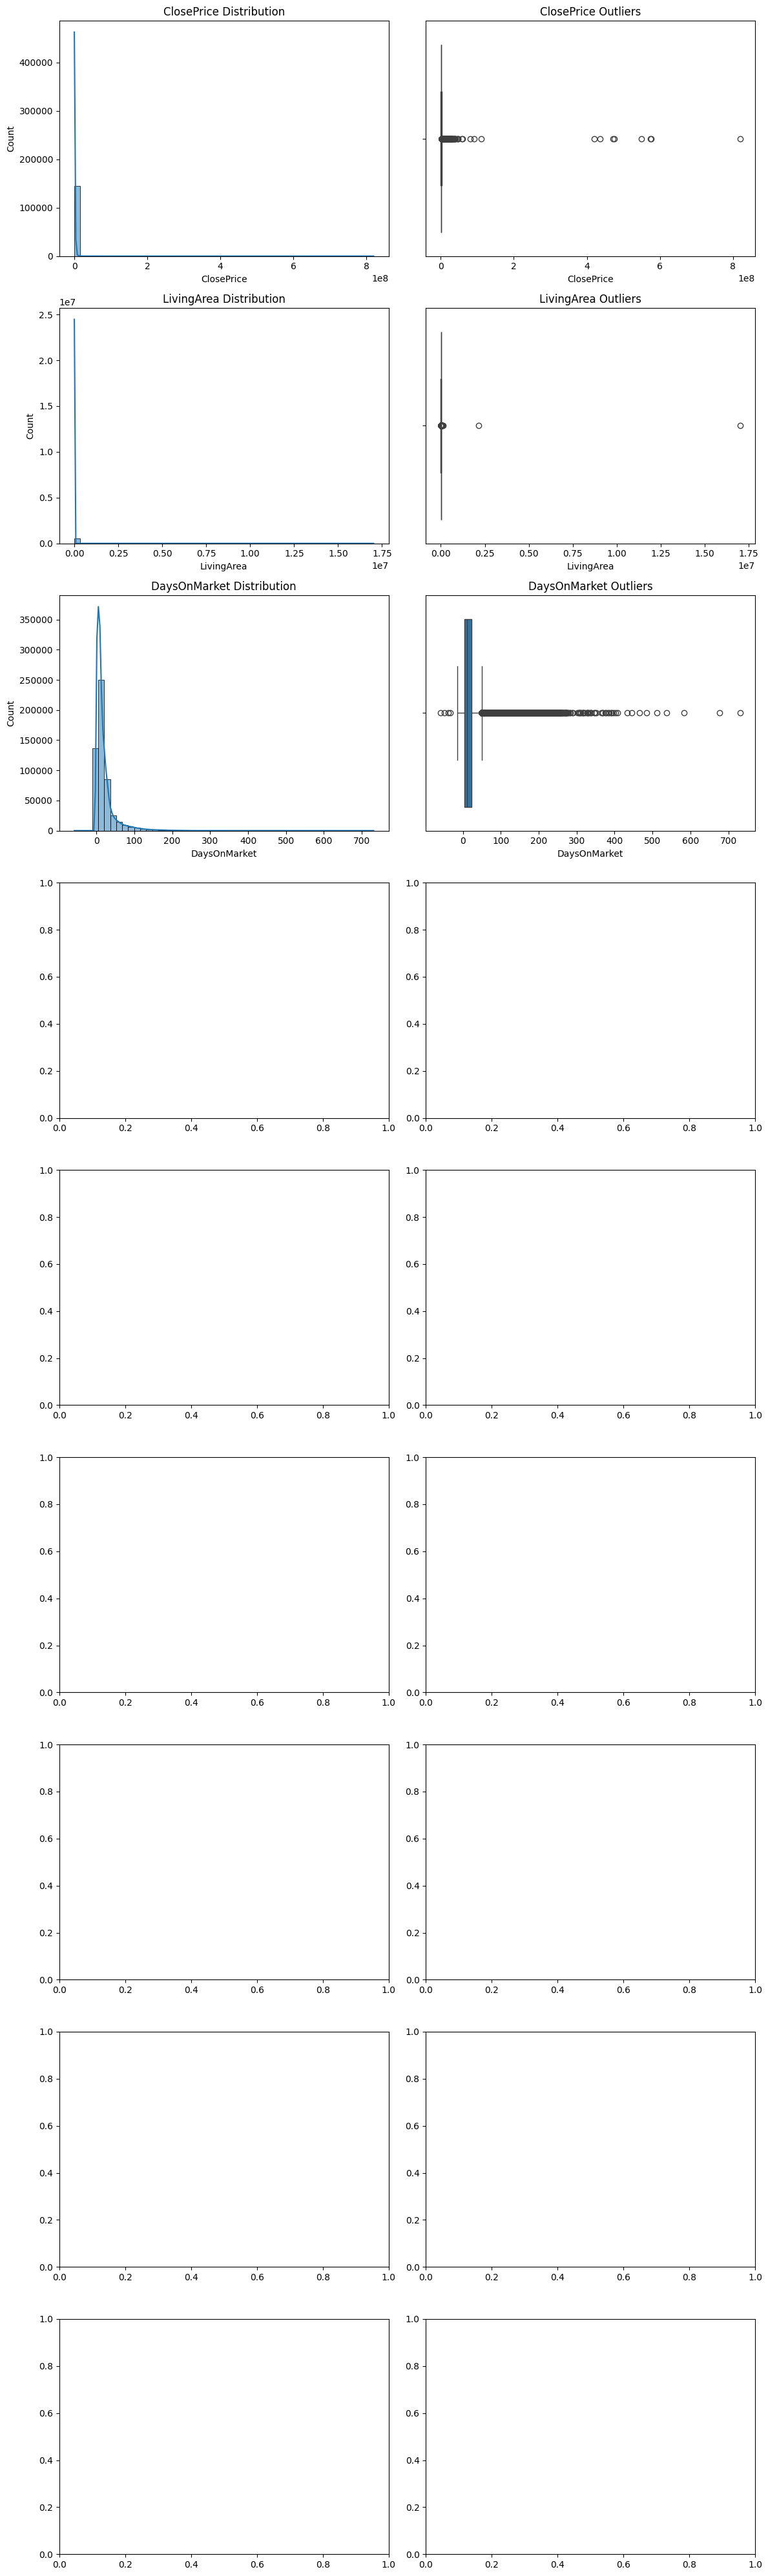

In [38]:
# Graphs
fig, axes = plt.subplots(nrows=9, ncols=2, figsize=(12,40))

for i, col in enumerate(core_numeric):
    # Histogram
    sns.histplot(listing_df[col],bins=50,kde=True, ax=axes[i,0])
    axes[i,0].set_title(f'{col} Distribution')
    
    # Boxplot
    sns.boxplot(x=listing_df[col], ax=axes[i,1])
    axes[i,1].set_title(f'{col} Outliers')
plt.tight_layout()
plt.show()

### Mortgage Rate Enrichment

In [39]:
import pandas as pd

# 1. Fetch mortgage rate data directly from the URL (Handbook Method)
# FIX: Change 'DATE' to 'observation_date'
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"
mortgage = pd.read_csv(url, parse_dates=['observation_date'])

# 2. Rename columns so 'observation_date' becomes 'date' for the pipeline
mortgage.columns = ['date', 'rate_30yr_fixed']

# 3. Resample weekly rates to monthly averages
mortgage['year_month'] = mortgage['date'].dt.to_period('M')
mortgage_monthly = mortgage.groupby('year_month')['rate_30yr_fixed'].mean().reset_index()

# 4. Create a matching year_month key on the MLS dataset using ListingContractDate
listing_df['year_month'] = pd.to_datetime(listing_df['ListingContractDate']).dt.to_period('M')

# 5. Merge the dataframes together
listing_with_rates_df = listing_df.merge(mortgage_monthly, on='year_month', how='left')

# 6. Check for missing values and preview the success
print(f"Null mortgage rates: {listing_with_rates_df['rate_30yr_fixed'].isnull().sum()}")
print("\nPreview of the enriched dataset:")
print(listing_with_rates_df[['ListingContractDate', 'year_month', 'ListPrice', 'rate_30yr_fixed']].head())

Null mortgage rates: 0

Preview of the enriched dataset:
  ListingContractDate year_month   ListPrice  rate_30yr_fixed
0          2024-01-01    2024-01   1340000.0           6.6425
1          2024-01-24    2024-01   2500000.0           6.6425
2          2024-01-12    2024-01   3150000.0           6.6425
3          2024-01-20    2024-01   3090000.0           6.6425
4          2024-01-12    2024-01  12725000.0           6.6425


In [40]:
# Export to csv
# listing_with_rates.to_csv('Listing_With_Rates.csv', index=False)

## Data Cleaning and Preparation

In [41]:
# Convert data fields to datetime format
date_cols = ['CloseDate','ListingContractDate','PurchaseContractDate','ContractStatusChangeDate']
for col in date_cols:
    if col in listing_with_rates_df.columns:
        listing_with_rates_df[col]= pd.to_datetime(listing_with_rates_df[col])


In [42]:
# Check for duplicates
listing_with_rates_df[listing_with_rates_df.duplicated(subset='ListingKey')]
listing_with_rates_df = listing_with_rates_df.drop_duplicates(subset=['ListingKey'], keep='last') # Keep the most recent property with the listing key

In [43]:
# Drop duplicate columns
listing_with_rates_df = listing_with_rates_df.drop(columns=[col for col in listing_with_rates_df.columns if col.endswith('.1')])

In [44]:
# FIX: Drop rows if missing critical value (ListPrice instead of ClosePrice)
must_columns = ['ListingKey', 'ListPrice', 'City']
listing_with_rates_df = listing_with_rates_df.dropna(subset=must_columns)

In [45]:
# Fill in missing counts with '0'
zero_fill_cols = ['GarageSpaces', 'ParkingTotal', 'FireplacesTotal']

for col in zero_fill_cols:
    if col in listing_with_rates_df.columns:
        listing_with_rates_df[col] = listing_with_rates_df[col].fillna(0)

# Fill in missing Yes/No features with 'No'
fill_no_cols = ['PoolPrivateYN', 'ViewYN', 'CoolingYN', 'HeatingYN']
for col in fill_no_cols:
    if col in listing_with_rates_df.columns:
        listing_with_rates_df[col] = listing_with_rates_df[col].fillna(False)

# Fill in missing categorical data with "Unknown"
cat_fill_cols = ['ArchitectureStyle', 'Heating', 'Cooling', 'WaterSource']
for col in cat_fill_cols:
    if col in listing_with_rates_df.columns:
        listing_with_rates_df[col] = listing_with_rates_df[col].fillna('Unknown')

# Fill in missing numerical values
num_fill_cols = ['LotSizeArea', 'YearBuilt']
for col in num_fill_cols:
    if col in listing_with_rates_df.columns:
        col_median = listing_with_rates_df[col].median()
        listing_with_rates_df[col] = listing_with_rates_df[col].fillna(col_median)


In [46]:
# Drop missing Living Area
listing_with_rates_df = listing_with_rates_df.dropna(subset='LivingArea')

In [47]:
# A listing cannot go under contract before it is listed
invalid_contracts = (listing_with_rates_df['ListingContractDate'] > listing_with_rates_df['PurchaseContractDate']) & listing_with_rates_df['PurchaseContractDate'].notna()

listing_with_rates_df['contract_before_listing_flag'] = invalid_contracts
listing_with_rates_df['negative_timeline_flag'] = listing_with_rates_df['DaysOnMarket'] < 0

print(f"Contract Date Errors: {listing_with_rates_df['contract_before_listing_flag'].sum()}")
print(f"Negative Timeline Errors: {listing_with_rates_df['negative_timeline_flag'].sum()}")

Contract Date Errors: 269
Negative Timeline Errors: 29


In [48]:
# Geographic Data Checks
print(f"Number of rows before cleaning: {listing_with_rates_df.shape[0]}")
listing_with_rates_df['missing_coords'] = listing_with_rates_df['Latitude'].isnull() | listing_with_rates_df['Longitude'].isnull()
listing_with_rates_df['sentinel_coords'] = (listing_with_rates_df['Latitude'] == 0) | (listing_with_rates_df['Longitude'] == 0)
listing_with_rates_df['cal_coords'] = listing_with_rates_df['Longitude'] > 0

listing_with_rates_df = listing_with_rates_df[
    (listing_with_rates_df['missing_coords'] == False) &
    (listing_with_rates_df['sentinel_coords'] == False) &
    (listing_with_rates_df['cal_coords'] == False) &
    (listing_with_rates_df['negative_timeline_flag'] == False) &
    (listing_with_rates_df['contract_before_listing_flag'] == False)
]
# Verify row numbers
print(f'Number of rows after cleaning: {listing_with_rates_df.shape[0]}')

Number of rows before cleaning: 538993
Number of rows after cleaning: 458680


In [49]:
# Filter out Living Area for reasonable values
listing_with_rates_df = listing_with_rates_df[listing_with_rates_df['LivingArea'].isna() | (listing_with_rates_df['LivingArea'] > 0)]

# Filter bad coordinates (longitude and latitude)
listing_with_rates_df = listing_with_rates_df[listing_with_rates_df['Latitude'].isna() | listing_with_rates_df['Longitude'].between(-124,-114)]

# Filter out DaysOnMarket
listing_with_rates_df = listing_with_rates_df[listing_with_rates_df['DaysOnMarket'].isna() | (listing_with_rates_df['DaysOnMarket']>= 0)]

In [50]:
# Export to csv
# listing_with_rates_df.to_csv('CRMLS_Listing_With_Rates_Cleaned.csv', index=False)

## Feature Engineering 
Some Week 6 metrics require closed transactions (`CloseDate`, `ClosePrice`). Because the listings dataset includes active and pending records, those sold-only features are not engineered here. Instead, this notebook focuses on listing-stage metrics derived from `ListingContractDate`, `ListPrice`, `LivingArea`, and `DaysOnMarket`.

In [51]:
# Get year, month, yrmo from 'ListingContractDate'
listing_with_rates_df['Year'] = listing_with_rates_df['ListingContractDate'].dt.year
listing_with_rates_df['Month'] = listing_with_rates_df['ListingContractDate'].dt.month
listing_with_rates_df['YrMo'] = listing_with_rates_df['ListingContractDate'].dt.to_period('M').astype(str)
listing_with_rates_df['ListPricePerSqFt'] = listing_with_rates_df['ListPrice'] / listing_with_rates_df['LivingArea']

columns = ['Year', 'Month', 'YrMo', 'ListPricePerSqFt']
listing_with_rates_df[columns].head()

,Year,Month,YrMo,ListPricePerSqFt
0,2024,1,2024-01,1029.976941
1,2024,1,2024-01,896.700143
2,2024,1,2024-01,969.230769
3,2024,1,2024-01,414.431330
4,2024,1,2024-01,5482.550625


In [53]:

# 1. Active Listings by Property SubType
listing_property_segment = listing_with_rates_df.groupby('PropertySubType').agg({
    'ListPrice': 'median',
    'ListPricePerSqFt': 'median',
    'DaysOnMarket': 'mean',
    'ListingKey': 'count'
}).rename(columns={'ListingKey': 'Active_Listings'}).reset_index()

print(f"Active Listings by Property Type\n{'*' * 30}\n{listing_property_segment}\n")

# 2. Active Listings by County
listing_county_segment = listing_with_rates_df.groupby('CountyOrParish').agg({
    'ListPrice': 'median',
    'DaysOnMarket': 'mean',
    'ListingKey': 'count'
}).rename(columns={'ListingKey': 'Active_Listings'}).reset_index()

print(f"Active Listings by County\n{'*' * 30}\n{listing_county_segment}\n")

Active Listings by Property Type
******************************
          PropertySubType  ListPrice  ListPricePerSqFt  DaysOnMarket  \
0               Apartment  1900000.0        550.405562     23.000000   
1                BoatSlip   215000.0       1875.000000     21.567164   
2                   Cabin   299000.0        347.222222     25.303345   
3             CoOwnership   570000.0        436.666667     10.377358   
4             Condominium   638838.0        574.711925     22.776424   
5           DeededParking   572000.0        345.823409     19.250000   
6                  Duplex   975000.0        552.864766     20.218856   
7                    Farm  2499500.0       1151.850472     46.093750   
8                    Loft   665000.0        550.793651     19.035088   
9        ManufacturedHome   359950.0        215.277778     35.000000   
10     ManufacturedOnLand   329000.0        234.030837     22.476873   
11               MixedUse   850000.0        484.652666     25.661538   


In [52]:
# Export to csv
# listing_with_rates_df.to_csv('Listing_With_Rates_Engineered.csv', index=False)